# Volcaniarm reach — training analysis

Reads the rsl_rl TensorBoard event file + the per-checkpoint settled-error rollouts
(`settled_error_iter*.npz`, from `source/volcaniarm/scripts/rsl_rl/eval_settled_error.py`)
and renders thesis-quality figures you can edit freely.

**Kernel:** `isaaclab_env` (has `tensorboard`, `numpy`, `matplotlib`). No Isaac Sim needed.

In [1]:
# --- config: edit these ---------------------------------------------------
from pathlib import Path
import glob, os

_runs = sorted(glob.glob('../logs/reach/rsl_rl/volcaniarm_reach/*/'), key=os.path.getmtime, reverse=True)
if not _runs:
    raise SystemExit('No reach runs found under ../logs/reach/rsl_rl/volcaniarm_reach/')
# Default: newest run that has settled-error data, so the analysis works out of
# the box. To pick another run, set RUN explicitly, e.g.:
#   RUN = Path(_runs[0])  # newest run regardless of data
#   RUN = Path('../logs/reach/rsl_rl/volcaniarm_reach/2026-05-30_18-07-05')
_has = lambda r: bool(glob.glob(str(Path(r) / 'plots' / 'settled_error*.npz')))
RUN = next((Path(r) for r in _runs if _has(r)), Path(_runs[0]))
SMOOTH = 0.85          # EMA weight for the curves (higher = smoother)
SETTLE_WINDOW_S = 1.0  # 'settled' = last this-many seconds before each target resample
print('Run:', RUN.name, '| settled npz files:', len(glob.glob(str(RUN / 'plots' / 'settled_error*.npz'))))

Run: 2026-05-30_18-07-05 | settled npz files: 3


In [2]:
import numpy as np, re
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.labelsize': 10,
                     'axes.titlesize': 10, 'axes.grid': True, 'grid.alpha': 0.3})
(RUN / 'plots').mkdir(exist_ok=True)

_ev = sorted(glob.glob(str(RUN / 'events.out.tfevents.*')))[-1]
acc = EventAccumulator(_ev, size_guidance={'scalars': 0}); acc.Reload()

def scalar(tag):
    s = acc.Scalars(tag); return np.array([p.step for p in s]), np.array([p.value for p in s])

def ema(y, w):
    out, a, d = [], 0.0, 0.0
    for v in y:
        a = w * a + (1 - w) * v; d = w * d + (1 - w); out.append(a / d)
    return np.array(out)

def curve(tag, ylabel, fname=None):
    x, y = scalar(tag)
    fig, ax = plt.subplots(figsize=(5, 3.2))
    ax.plot(x, y, color='#1f77b4', alpha=0.15, lw=1)        # faint raw
    ax.plot(x, ema(y, SMOOTH), color='#1f77b4', lw=1.8)     # smoothed
    ax.set_xlabel('Training iteration'); ax.set_ylabel(ylabel); ax.margins(x=0.01)
    fig.tight_layout()
    return ax

def load_settled():
    """{iteration: npz} for every settled_error*.npz in the run."""
    out = {}
    for f in sorted(glob.glob(str(RUN / 'plots' / 'settled_error*.npz'))):
        d = np.load(f)
        m = re.search(r'iter(\d+)', os.path.basename(f))
        it = int(d['iteration']) if 'iteration' in d.files else (int(m.group(1)) if m else -1)
        if it >= 0:            # skip stray untagged files
            out[it] = d
    return out

## Learning curves

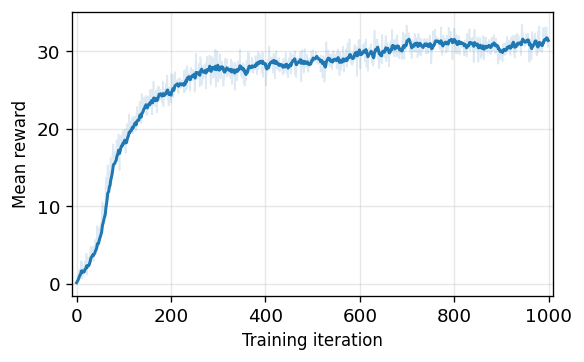

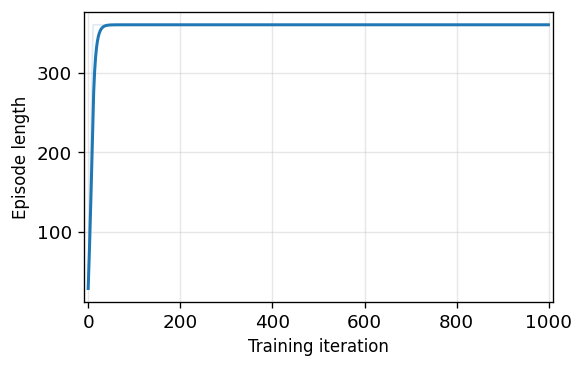

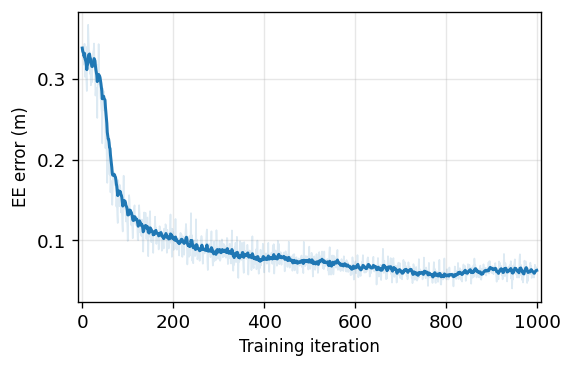

In [3]:
curve('Train/mean_reward', 'Mean reward', 'reward');
curve('Train/mean_episode_length', 'Episode length', 'episode_length');
curve('Metrics/ee_pose/position_error', 'EE error (m)', 'ee_position_error_mean');
plt.show()

## Settled (steady-state) error

The episode-mean above folds in the transient right after each target teleport (targets
jump up to ~1 m away every 4 s). Using the per-step rollout we isolate the **settled**
error — precision once the arm has arrived — and show how it sharpens over training.

In [4]:
_settled = load_settled()
if not _settled:
    raise FileNotFoundError(
        f"No settled_error*.npz in run '{RUN.name}'. Generate it (needs Isaac) with:\n"
        f"  ~/isaac/IsaacLab/isaaclab.sh -p source/volcaniarm/scripts/rsl_rl/eval_settled_error.py "
        f"--task Volcaniarm-Reach-Play-v0 --num_envs 64 --steps 1200 --headless --checkpoint <run>/model_<N>.pt")

ITERS = sorted(_settled)
d = _settled[ITERS[-1]]                     # final checkpoint -> headline stats
err, tleft = d['error'], d['time_left']
period, step_dt = float(d['resample_period']), float(d['step_dt'])
since = period - tleft
settled = err[tleft < SETTLE_WINDOW_S]
print(f'final checkpoint: iter {ITERS[-1]}   (iterations available: {ITERS})')
print(f'episode-mean (all steps)        : {err.mean()*100:6.2f} cm')
print(f'SETTLED (last {SETTLE_WINDOW_S:.1f}s pre-resample): '
      f'mean {settled.mean()*100:5.2f} cm | median {np.median(settled)*100:5.2f} cm | '
      f'p95 {np.percentile(settled,95)*100:5.2f} cm')
print(f'fraction of settled targets within 2 cm: {(settled < 0.02).mean()*100:.1f}%')

final checkpoint: iter 999   (iterations available: [50, 500, 999])
episode-mean (all steps)        :   8.82 cm
SETTLED (last 1.0s pre-resample): mean  7.82 cm | median  0.75 cm | p95 35.53 cm
fraction of settled targets within 2 cm: 69.4%


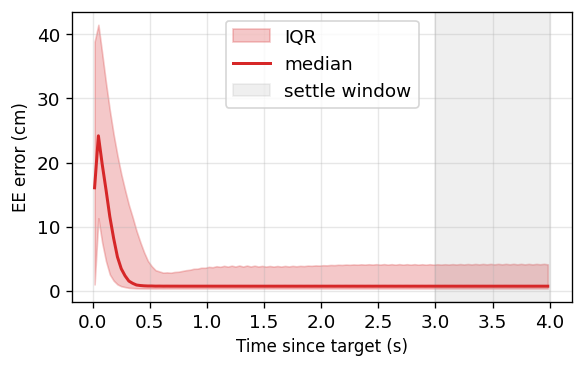

In [5]:
# Error vs time since target appeared (final policy), median + IQR
nbins = int(round(period / step_dt)); bins = np.linspace(0, period, nbins + 1)
idx = np.clip(np.digitize(since.ravel(), bins) - 1, 0, nbins - 1); e = err.ravel()
med = np.array([np.median(e[idx == b]) if (idx == b).any() else np.nan for b in range(nbins)])
q1  = np.array([np.percentile(e[idx == b], 25) if (idx == b).any() else np.nan for b in range(nbins)])
q3  = np.array([np.percentile(e[idx == b], 75) if (idx == b).any() else np.nan for b in range(nbins)])
t = 0.5 * (bins[:-1] + bins[1:])
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.fill_between(t, q1*100, q3*100, alpha=0.25, color='#d62728', label='IQR')
ax.plot(t, med*100, color='#d62728', lw=1.8, label='median')
ax.axvspan(period - SETTLE_WINDOW_S, period, color='gray', alpha=0.12, label='settle window')
ax.set_xlabel('Time since target (s)'); ax.set_ylabel('EE error (cm)'); ax.legend()
fig.tight_layout()
plt.show()

### Settled-error distribution across training
One panel per checkpoint — watch the mass shift toward sub-cm as the policy learns.

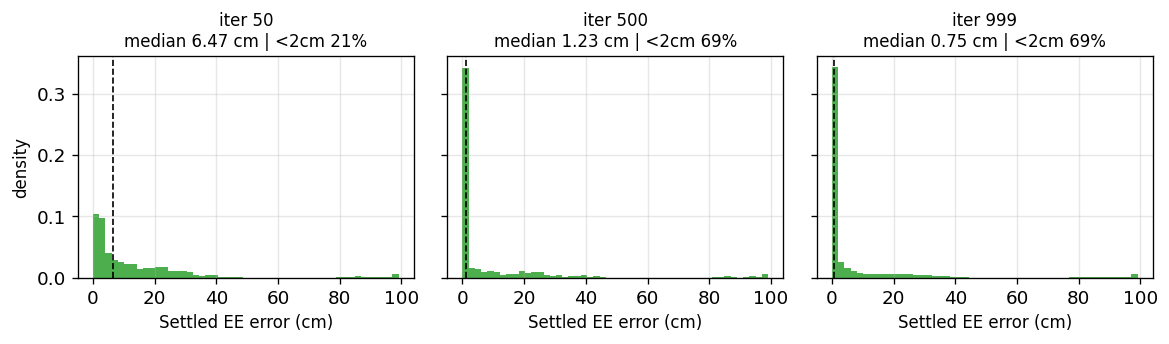

In [6]:
# Histogram of settled error at each saved checkpoint.
# density=True so panels stay comparable even if env counts differ (final = 4096 envs).
iters = sorted(_settled)
sets = {i: _settled[i]['error'][_settled[i]['time_left'] < SETTLE_WINDOW_S] * 100 for i in iters}
xmax = np.percentile(np.concatenate(list(sets.values())), 99)   # clip extreme tail for readability
bins = np.linspace(0, xmax, 50)
fig, axes = plt.subplots(1, len(iters), figsize=(3.3*len(iters), 3.0), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, it in zip(axes, iters):
    s = sets[it]
    ax.hist(np.clip(s, 0, xmax), bins=bins, color='#2ca02c', alpha=0.85, density=True)
    ax.axvline(np.median(s), color='k', ls='--', lw=1)
    ax.set_title(f'iter {it}\nmedian {np.median(s):.2f} cm | <2cm {(s<2).mean()*100:.0f}%')
    ax.set_xlabel('Settled EE error (cm)')
axes[0].set_ylabel('density')
fig.tight_layout()
plt.show()

## Play rollout EE error

The deterministic final policy evaluated via `play.py --log_ee_error` (`play_ee_error.npz`). Error-vs-time settling on the left, settled-error distribution on the right.

play rollout: iter 999 | 1200 steps x 64 env(s)
episode-mean 8.94 cm | settled median 0.74 cm | within 2 cm 70.4%


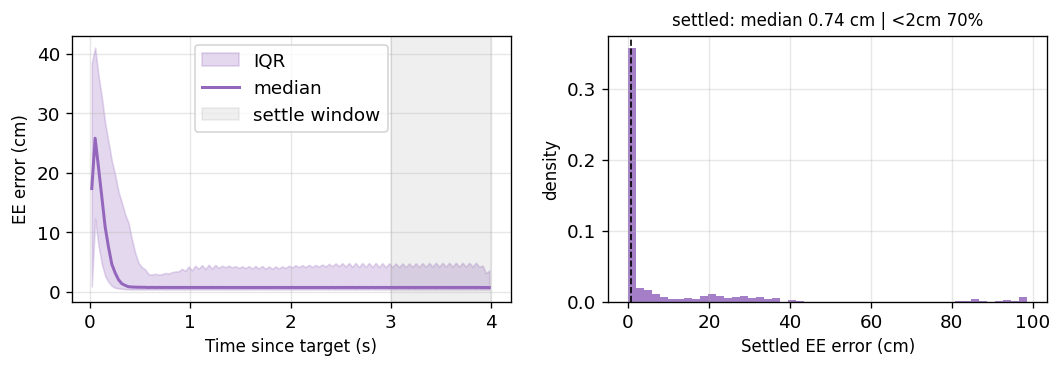

In [7]:
# --- Play rollout (play.py --log_ee_error -> play_ee_error.npz) ---
_pf = RUN / 'plots' / 'play_ee_error.npz'
if not _pf.exists():
    print(f'No play_ee_error.npz in {RUN.name}. Run play.py with --log_ee_error to create it.')
else:
    p = np.load(_pf)
    perr, ptl = p['error'], p['time_left']
    pper, pdt = float(p['resample_period']), float(p['step_dt'])
    psince = pper - ptl
    pset = perr[ptl < SETTLE_WINDOW_S]
    print(f"play rollout: iter {int(p['iteration'])} | {perr.shape[0]} steps x {perr.shape[1]} env(s)")
    print(f'episode-mean {perr.mean()*100:.2f} cm | settled median {np.median(pset)*100:.2f} cm | '
          f'within 2 cm {(pset<0.02).mean()*100:.1f}%')
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
    nb_ = int(round(pper/pdt)); bn = np.linspace(0, pper, nb_+1)
    ix = np.clip(np.digitize(psince.ravel(), bn)-1, 0, nb_-1); ev = perr.ravel()
    md_ = np.array([np.median(ev[ix==b]) if (ix==b).any() else np.nan for b in range(nb_)])
    q1 = np.array([np.percentile(ev[ix==b],25) if (ix==b).any() else np.nan for b in range(nb_)])
    q3 = np.array([np.percentile(ev[ix==b],75) if (ix==b).any() else np.nan for b in range(nb_)])
    tt = 0.5*(bn[:-1]+bn[1:])
    a1.fill_between(tt, q1*100, q3*100, alpha=0.25, color='#9467bd', label='IQR')
    a1.plot(tt, md_*100, color='#9467bd', lw=1.8, label='median')
    a1.axvspan(pper-SETTLE_WINDOW_S, pper, color='gray', alpha=0.12, label='settle window')
    a1.set_xlabel('Time since target (s)'); a1.set_ylabel('EE error (cm)'); a1.legend()
    xm = np.percentile(pset, 99)*100
    a2.hist(np.clip(pset*100, 0, xm), bins=50, color='#9467bd', alpha=0.85, density=True)
    a2.axvline(np.median(pset)*100, color='k', ls='--', lw=1)
    a2.set_title(f'settled: median {np.median(pset)*100:.2f} cm | <2cm {(pset<0.02).mean()*100:.0f}%')
    a2.set_xlabel('Settled EE error (cm)'); a2.set_ylabel('density')
    fig.tight_layout(); plt.show()